<a href="https://colab.research.google.com/github/MaivyAyman/SoftPro/blob/Master/Copy_of_SOFT_PRO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 # Importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from google.colab import drive
SEED=30


In [ ]:
# Load the dataset
data = pd.read_csv('TUANDROMD.csv')



In [ ]:
# Display the first few rows of the dataset
data.head()


,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,malware
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,malware
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,malware
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,malware
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,malware


In [ ]:
data.dtypes

,0
ACCESS_ALL_DOWNLOADS,float64
ACCESS_CACHE_FILESYSTEM,float64
ACCESS_CHECKIN_PROPERTIES,float64
ACCESS_COARSE_LOCATION,float64
ACCESS_COARSE_UPDATES,float64
...,...
Landroid/telephony/TelephonyManager;->getSimOperatorName,float64
Landroid/telephony/TelephonyManager;->getSimCountryIso,float64
Landroid/telephony/TelephonyManager;->getSimSerialNumber,float64
Lorg/apache/http/impl/client/DefaultHttpClient;->execute,float64


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4465 entries, 0 to 4464
Columns: 242 entries, ACCESS_ALL_DOWNLOADS to Label
dtypes: float64(241), object(1)
memory usage: 8.2+ MB


In [ ]:
# Define class labels
classes = {0: 'goodware', 1: 'malware'}

# Display value counts of target variable
print(data['Label'].value_counts())


Label
malware     3565
goodware     899
Name: count, dtype: int64


**Preprocessing**


In [ ]:
# total null elements

data.isnull().sum()[data.isnull().sum() > 0]

,0
ACCESS_ALL_DOWNLOADS,1
ACCESS_CACHE_FILESYSTEM,1
ACCESS_CHECKIN_PROPERTIES,1
ACCESS_COARSE_LOCATION,1
ACCESS_COARSE_UPDATES,1
...,...
Landroid/telephony/TelephonyManager;->getSimOperatorName,1
Landroid/telephony/TelephonyManager;->getSimCountryIso,1
Landroid/telephony/TelephonyManager;->getSimSerialNumber,1
Lorg/apache/http/impl/client/DefaultHttpClient;->execute,1


In [ ]:
# Drop rows with missing values
data.dropna(inplace=True)



In [ ]:
# total null elements

data.isnull().sum()[data.isnull().sum() > 0]

,0


In [ ]:
# Display the first few rows of the dataset
data.head()


,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,malware
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,malware
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,malware
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,malware
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,malware


In [ ]:

print(f"Dataset has {data.shape[0]} rows and {data.shape[1]} features after deleting rows")

Dataset has 4464 rows and 242 features after deleting rows


In [ ]:
data['Label'] = data['Label'].replace({'malware' : 1 , 'goodware':0})
data['Label'].unique()

<ipython-input-14-4cae10b141ca>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Label'] = data['Label'].replace({'malware' : 1 , 'goodware':0})


array([1, 0])

In [ ]:
# Separate features and target variable
X = data.drop('Label', axis=1)
y = data['Label']

In [ ]:
# Check data types of the features
print("Data types before handling object columns:")
print(X.dtypes)


Data types before handling object columns:
ACCESS_ALL_DOWNLOADS                                        float64
ACCESS_CACHE_FILESYSTEM                                     float64
ACCESS_CHECKIN_PROPERTIES                                   float64
ACCESS_COARSE_LOCATION                                      float64
ACCESS_COARSE_UPDATES                                       float64
                                                             ...   
Landroid/telephony/TelephonyManager;->getSimOperator        float64
Landroid/telephony/TelephonyManager;->getSimOperatorName    float64
Landroid/telephony/TelephonyManager;->getSimCountryIso      float64
Landroid/telephony/TelephonyManager;->getSimSerialNumber    float64
Lorg/apache/http/impl/client/DefaultHttpClient;->execute    float64
Length: 241, dtype: object


In [ ]:

# Identify object columns
object_cols = X.select_dtypes(include='object').columns

# If there are object columns, attempt to convert them or handle them
if len(object_cols) > 0:
    print(f"\nFound object columns: {list(object_cols)}")
    print("Attempting to convert object columns to numeric, coercing errors...")

    for col in object_cols:
        # Convert the column to numeric, coercing errors will turn unparseable values into NaN
        X[col] = pd.to_numeric(X[col], errors='coerce')

    # After coercion, check for and handle any NaNs introduced
    print("\nChecking for NaNs after converting object columns:")
    nans_after_coercion = X.isnull().sum()
    nans_after_coercion = nans_after_coercion[nans_after_coercion > 0]
    if len(nans_after_coercion) > 0:
        print("NaNs found in columns after coercion:")
        print(nans_after_coercion)
        # Decide how to handle these NaNs: drop rows, impute, etc.
        # For simplicity, let's drop rows with NaNs for now.
        original_rows = X.shape[0]
        X.dropna(inplace=True)
        y = y[X.index] # Keep y aligned with X after dropping rows
        print(f"Dropped {original_rows - X.shape[0]} rows containing NaNs introduced by coercion.")
    else:
        print("No NaNs introduced by coercion.")

# Verify data types are now numerical before proceeding
print("\nData types after handling object columns:")
print(X.dtypes)


Data types after handling object columns:
ACCESS_ALL_DOWNLOADS                                        float64
ACCESS_CACHE_FILESYSTEM                                     float64
ACCESS_CHECKIN_PROPERTIES                                   float64
ACCESS_COARSE_LOCATION                                      float64
ACCESS_COARSE_UPDATES                                       float64
                                                             ...   
Landroid/telephony/TelephonyManager;->getSimOperator        float64
Landroid/telephony/TelephonyManager;->getSimOperatorName    float64
Landroid/telephony/TelephonyManager;->getSimCountryIso      float64
Landroid/telephony/TelephonyManager;->getSimSerialNumber    float64
Lorg/apache/http/impl/client/DefaultHttpClient;->execute    float64
Length: 241, dtype: object


In [ ]:
# Display the first few rows of the dataset
data.head()


,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [ ]:
# Calculate feature importance using Mutual Information and Point-Biserial correlation
point_biserial_coefs = []
for i in range(X.shape[1]):
    coef = stats.pointbiserialr(X.iloc[:, i], y)[0]
    point_biserial_coefs.append(coef)

mutual_inf = mutual_info_classif(X, y)

/usr/local/lib/python3.11/dist-packages/scipy/stats/_stats_py.py:5405: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


In [ ]:
# Create a DataFrame to store feature importance
feature_importance = pd.DataFrame({'Mutual Inf': mutual_inf, 'Point-BiSerial': point_biserial_coefs}, index=X.columns)

In [ ]:
# Sort feature importance based on 'Point-BiSerial' column in descending order
sorted_feature_importance = feature_importance.sort_values(by='Point-BiSerial', ascending=False)

print(sorted_feature_importance)

                           Mutual Inf  Point-BiSerial
RECEIVE_BOOT_COMPLETED       0.239876        0.760417
GET_TASKS                    0.161071        0.563214
WAKE_LOCK                    0.085682        0.472105
KILL_BACKGROUND_PROCESSES    0.105675        0.438312
SYSTEM_ALERT_WINDOW          0.042502        0.281178
...                               ...             ...
SEND                         0.000492             NaN
WRITE                        0.000000             NaN
WRITE_AVSETTING              0.005588             NaN
WRITE_DATA                   0.011634             NaN
WRITE_DATABASES              0.011215             NaN

[241 rows x 2 columns]


In [ ]:
feature_importance.sort_values(by = 'Mutual Inf', ascending = False)


,Mutual Inf,Point-BiSerial
RECEIVE_BOOT_COMPLETED,0.239876,0.760417
Ljava/net/URL;->openConnection,0.211034,-0.712211
Landroid/location/LocationManager;->getLastKgoodwarewnLocation,0.166497,-0.653875
GET_TASKS,0.161071,0.563214
KILL_BACKGROUND_PROCESSES,0.105675,0.438312
...,...,...
WRITE_SMS,0.000000,0.052862
Landroid/hardware/Camera;->open,0.000000,0.091491
Landroid/hardware/Camera;->takePicture,0.000000,0.084475
Lcom/google/android/gms/location/LocationClient;->getLastLocation,0.000000,-0.008532


In [ ]:
# drop highly correlated features
X.drop(['RECEIVE_BOOT_COMPLETED', 'GET_TASKS', 'Ljava/net/URL;->openConnection'], axis = 1, inplace = True)

In [ ]:
print(X.columns)


Index(['ACCESS_ALL_DOWNLOADS', 'ACCESS_CACHE_FILESYSTEM',
       'ACCESS_CHECKIN_PROPERTIES', 'ACCESS_COARSE_LOCATION',
       'ACCESS_COARSE_UPDATES', 'ACCESS_FINE_LOCATION',
       'ACCESS_LOCATION_EXTRA_COMMANDS', 'ACCESS_MOCK_LOCATION',
       'ACCESS_MTK_MMHW', 'ACCESS_NETWORK_STATE',
       ...
       'Landroid/content/pm/PackageManager;->getInstalledPackages',
       'Landroid/telephony/TelephonyManager;->getLine1Number',
       'Landroid/telephony/TelephonyManager;->getNetworkOperator',
       'Landroid/telephony/TelephonyManager;->getNetworkOperatorName',
       'Landroid/telephony/TelephonyManager;->getNetworkCountryIso',
       'Landroid/telephony/TelephonyManager;->getSimOperator',
       'Landroid/telephony/TelephonyManager;->getSimOperatorName',
       'Landroid/telephony/TelephonyManager;->getSimCountryIso',
       'Landroid/telephony/TelephonyManager;->getSimSerialNumber',
       'Lorg/apache/http/impl/client/DefaultHttpClient;->execute'],
      dtype='object', length=2

In [ ]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25, shuffle = True,random_state=101)

print('train samples ->', X_train.shape)
print('test samples ->', X_test.shape)

train samples -> (3348, 238)
test samples -> (1116, 238)


In [ ]:
# Scaling numerical data
MM = MinMaxScaler()
MM_fit = MM.fit(X_train)
X_train = MM_fit.transform(X_train)
X_test = MM_fit.transform(X_test)




----- Logistic Regression -----
Accuracy: 97.85%
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       228
           1       0.99      0.99      0.99       888

    accuracy                           0.98      1116
   macro avg       0.97      0.97      0.97      1116
weighted avg       0.98      0.98      0.98      1116



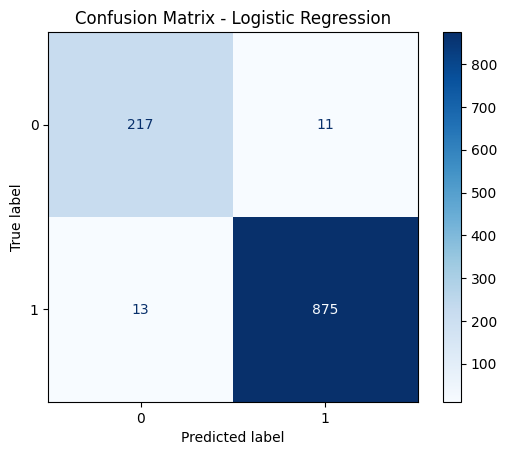



----- SVM (Linear Kernel) -----
Accuracy: 98.03%
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       228
           1       0.99      0.99      0.99       888

    accuracy                           0.98      1116
   macro avg       0.97      0.97      0.97      1116
weighted avg       0.98      0.98      0.98      1116



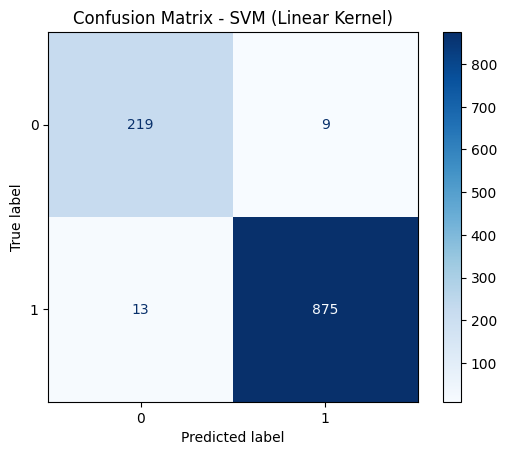



----- Gradient Boosting -----
Accuracy: 98.03%
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       228
           1       0.99      0.99      0.99       888

    accuracy                           0.98      1116
   macro avg       0.97      0.97      0.97      1116
weighted avg       0.98      0.98      0.98      1116



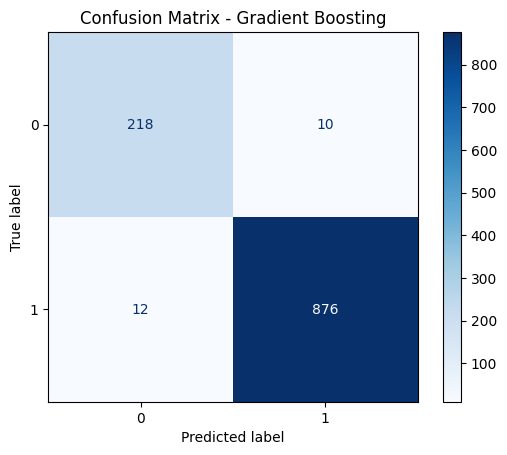

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "SVM (Linear Kernel)": SVC(kernel='linear', random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED)
}


metrics_no_selection = {}

for name, model in models.items():
    print(f"\n\n----- {name} -----")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    precision = precision_score(y_test, preds, average='weighted')
    recall = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')
    accuracy = accuracy_score(y_test, preds)

    metrics_no_selection[name] = {
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Accuracy': accuracy
    }

    print(f"Accuracy: {accuracy * 100:.2f}%")
    print("Classification Report:")
    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


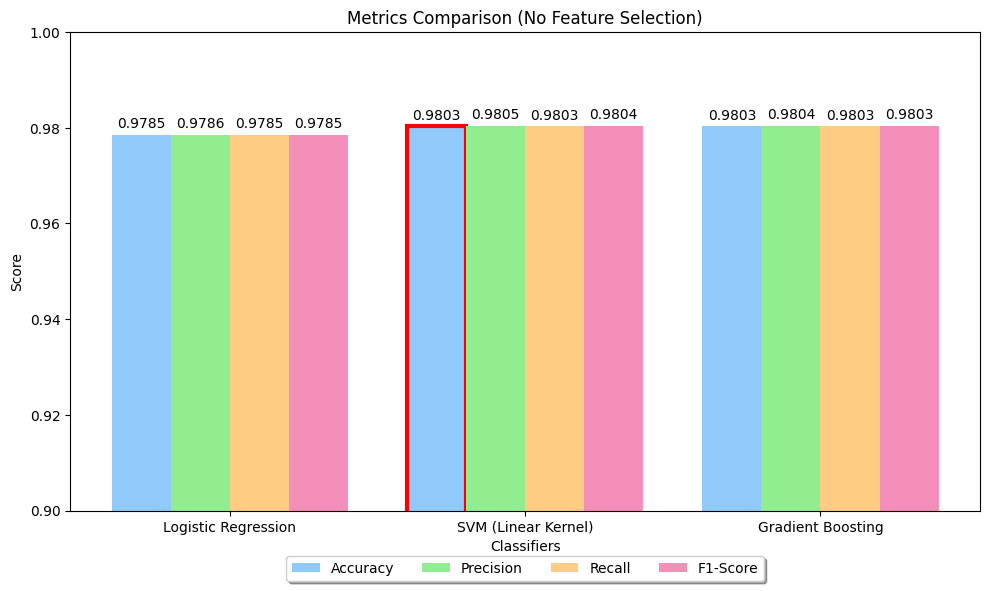

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# الموديلات
models = list(metrics_no_selection.keys())

# المتركس
accuracies = [metrics_no_selection[m]['Accuracy'] for m in models]
precisions = [metrics_no_selection[m]['Precision'] for m in models]
recalls = [metrics_no_selection[m]['Recall'] for m in models]
f1_scores = [metrics_no_selection[m]['F1-Score'] for m in models]

# ترتيب الأعمدة
x = np.arange(len(models))
width = 0.2  # عرض العمود

fig, ax = plt.subplots(figsize=(10,6))

# ألوان هادية
colors = ['#90cafa', '#90ee90', '#ffcc83', '#f48fba']

# الأعمدة
rects1 = ax.bar(x - 1.5*width, accuracies, width, label='Accuracy', color=colors[0])
rects2 = ax.bar(x - 0.5*width, precisions, width, label='Precision', color=colors[1])
rects3 = ax.bar(x + 0.5*width, recalls, width, label='Recall', color=colors[2])
rects4 = ax.bar(x + 1.5*width, f1_scores, width, label='F1-Score', color=colors[3])

max_idx = np.argmax(accuracies)
rects1[max_idx].set_edgecolor('red')
rects1[max_idx].set_linewidth(3)


# التعديلات
ax.set_xlabel('Classifiers')
ax.set_ylabel('Score')
ax.set_title('Metrics Comparison (No Feature Selection)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.9, 1)

# عرض القيم فوق الأعمدة
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

# Legend بشكل أفقي تحت الجرافيك
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08),
          fancybox=True, shadow=True, ncol=4)

plt.tight_layout()
plt.show()


## **GA**

In [ ]:

print(type(X_train))

<class 'numpy.ndarray'>


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def run_ga_for_classifier(model, model_name,
                          size, n_feat, n_parents, mutation_rate, n_gen,
                          X_train, X_test, y_train, y_test, classes, X):

    print(f"\n==============================================================")
    print(f"Running GA for {model_name}...")
    print(f"==============================================================\n")

    # Initialization of population
    def initialization_of_population(size, n_feat):
        population = []
        for _ in range(size):
            chromosome = np.ones(n_feat, dtype=bool)
            chromosome[:int(0.3 * n_feat)] = False
            np.random.shuffle(chromosome)
            population.append(chromosome)
        return population

    # Fitness score using model
    def fitness_score_ga(population):
        scores = []
        for chromosome in population:
            if np.sum(chromosome) == 0:  # Avoid empty feature sets
                scores.append(0)
            else:
                model.fit(X_train[:, chromosome], y_train)
                preds = model.predict(X_test[:, chromosome])
                scores.append(accuracy_score(y_test, preds))
        scores, population = np.array(scores), np.array(population)
        inds = np.argsort(scores)
        return list(scores[inds][::-1]), list(population[inds, :][::-1])

    # Selection
    def selection(pop_after_fit, n_parents):
        return pop_after_fit[:n_parents]

    # Crossover (handles odd-sized population)
    def crossover(pop_after_sel):
        pop_nextgen = pop_after_sel.copy()
        for i in range(0, len(pop_after_sel) - 1, 2):
            child_1 = pop_after_sel[i].copy()
            child_2 = pop_after_sel[i + 1].copy()
            point = len(child_1) // 2
            new_par = np.concatenate((child_1[:point], child_2[point:]))
            pop_nextgen.append(new_par)
        return pop_nextgen

    # Mutation
    def mutation(pop_after_cross, mutation_rate, n_feat):
        mutation_range = int(mutation_rate * n_feat)
        pop_next_gen = []
        for chromo in pop_after_cross:
            chromo = chromo.copy()
            rand_posi = np.random.randint(0, n_feat, mutation_range)
            for j in rand_posi:
                chromo[j] = not chromo[j]
            pop_next_gen.append(chromo)
        return pop_next_gen

    # Main GA loop
    def generations_ga():
        best_chromo = []
        best_score = []
        population_nextgen = initialization_of_population(size, n_feat)
        for i in range(n_gen):
            scores, pop_after_fit = fitness_score_ga(population_nextgen)
            if (i+1) % 5 == 0 or i == n_gen-1:
                print(f'Best score in generation {i+1}: {scores[0]:.4f}')
            pop_after_sel = selection(pop_after_fit, n_parents)
            pop_after_cross = crossover(pop_after_sel)
            population_nextgen = mutation(pop_after_cross, mutation_rate, n_feat)
            best_chromo.append(pop_after_fit[0])
            best_score.append(scores[0])
        return best_chromo, best_score


    # Run GA
    best_chromo, best_score = generations_ga()
    best_chromosome = best_chromo[-1]

    selected_features = X.columns[best_chromosome]
    print("---------------------- \n\n")
    print(f"\nBest features selected by GA for {model_name}:")
    print(selected_features)
    print("---------------------- \n\n")

    # Train final model with selected features
    X_train_ga = X_train[:, best_chromosome]
    X_test_ga = X_test[:, best_chromosome]
    model.fit(X_train_ga, y_train)
    pred_ga = model.predict(X_test_ga)

    # Evaluation
    acc_ga = accuracy_score(y_test, pred_ga)
    precision_ga = precision_score(y_test, pred_ga, average='weighted')
    recall_ga = recall_score(y_test, pred_ga, average='weighted')
    f1_ga = f1_score(y_test, pred_ga, average='weighted')


    print(f"\nAccuracy Score using selected features by GA for {model_name}: {acc_ga*100:.2f}%\n")

    print("Classification Report:")
    print(classification_report(y_test, pred_ga, target_names=list(classes.values())))

    # Confusion matrix
    cm_ga = confusion_matrix(y_test, pred_ga)
    cmd_ga = ConfusionMatrixDisplay(cm_ga, display_labels=list(classes.values()))

    fig, ax = plt.subplots(figsize=(5, 5))
    cmd_ga.plot(ax=ax, cmap='BuPu', colorbar=False)
    plt.title(f"Confusion Matrix using selected features by GA for {model_name}")
    plt.show()

    return best_chromosome, acc_ga, precision_ga, recall_ga, f1_ga


Running GA for Logistic Regression...

Best score in generation 5: 0.9776
Best score in generation 10: 0.9785
Best score in generation 15: 0.9767
Best score in generation 20: 0.9785
Best score in generation 25: 0.9758
Best score in generation 30: 0.9758
---------------------- 



Best features selected by GA for Logistic Regression:
Index(['ACCESS_ALL_DOWNLOADS', 'ACCESS_COARSE_LOCATION',
       'ACCESS_COARSE_UPDATES', 'ACCESS_FINE_LOCATION', 'ACCESS_MTK_MMHW',
       'ACCESS_PROVIDER', 'ACCESS_SERVICE', 'ACCESS_SHARED_DATA',
       'ACCESS_SUPERUSER', 'ACCESS_SURFACE_FLINGER',
       ...
       'Landroid/hardware/Camera;->open',
       'Landroid/hardware/Camera;->takePicture',
       'Landroid/telephony/TelephonyManager;->getCellLocation',
       'Landroid/content/pm/PackageManager;->getInstalledApplications',
       'Landroid/content/pm/PackageManager;->getInstalledPackages',
       'Landroid/telephony/TelephonyManager;->getLine1Number',
       'Landroid/telephony/TelephonyManager;

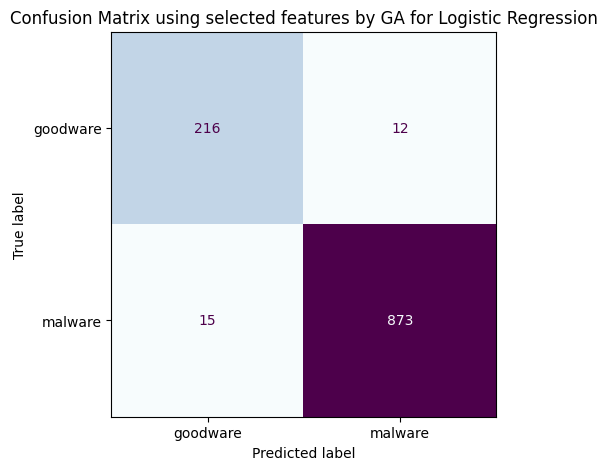


Running GA for SVM (Linear Kernel)...

Best score in generation 5: 0.9830
Best score in generation 10: 0.9803
Best score in generation 15: 0.9794
Best score in generation 20: 0.9803
Best score in generation 25: 0.9803
Best score in generation 30: 0.9830
---------------------- 



Best features selected by GA for SVM (Linear Kernel):
Index(['ACCESS_CACHE_FILESYSTEM', 'ACCESS_CHECKIN_PROPERTIES',
       'ACCESS_COARSE_UPDATES', 'ACCESS_FINE_LOCATION', 'ACCESS_MOCK_LOCATION',
       'ACCESS_MTK_MMHW', 'ACCESS_NETWORK_STATE', 'ACCESS_PROVIDER',
       'ACCESS_WIFI_STATE', 'ADD_VOICEMAIL',
       ...
       'Landroid/telephony/TelephonyManager;->getDeviceId',
       'Landroid/content/pm/PackageManager;->getInstalledApplications',
       'Landroid/content/pm/PackageManager;->getInstalledPackages',
       'Landroid/telephony/TelephonyManager;->getLine1Number',
       'Landroid/telephony/TelephonyManager;->getNetworkOperatorName',
       'Landroid/telephony/TelephonyManager;->getNetworkCountr

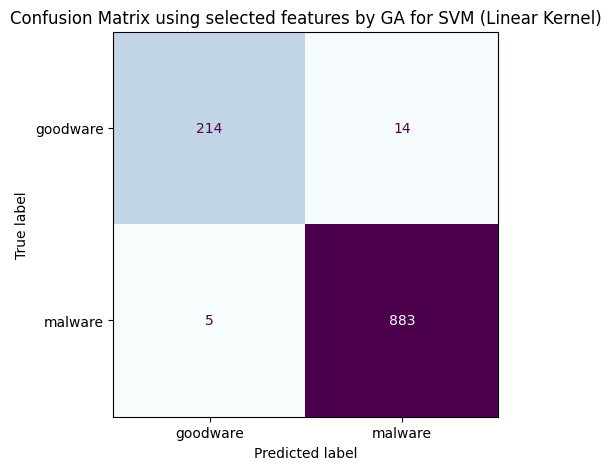


Running GA for Gradient Boosting...

Best score in generation 5: 0.9892
Best score in generation 10: 0.9857
Best score in generation 15: 0.9848
Best score in generation 20: 0.9839
Best score in generation 25: 0.9866
Best score in generation 30: 0.9848
---------------------- 



Best features selected by GA for Gradient Boosting:
Index(['ACCESS_CHECKIN_PROPERTIES', 'ACCESS_COARSE_LOCATION',
       'ACCESS_COARSE_UPDATES', 'ACCESS_MTK_MMHW', 'ACCESS_PROVIDER',
       'ACCESS_SUPERUSER', 'ACCESS_SURFACE_FLINGER', 'ACCESS_WIFI_STATE',
       'ACTIVITY_RECOGNITION', 'ACCOUNT_MANAGER',
       ...
       'Landroid/hardware/Camera;->open',
       'Landroid/hardware/Camera;->takePicture',
       'Landroid/telephony/SmsManager;->sendMultipartTextMessage',
       'Lcom/google/android/gms/location/LocationClient;->getLastLocation',
       'Landroid/telephony/TelephonyManager;->getDeviceId',
       'Landroid/content/pm/PackageManager;->getInstalledApplications',
       'Landroid/content/pm/Package

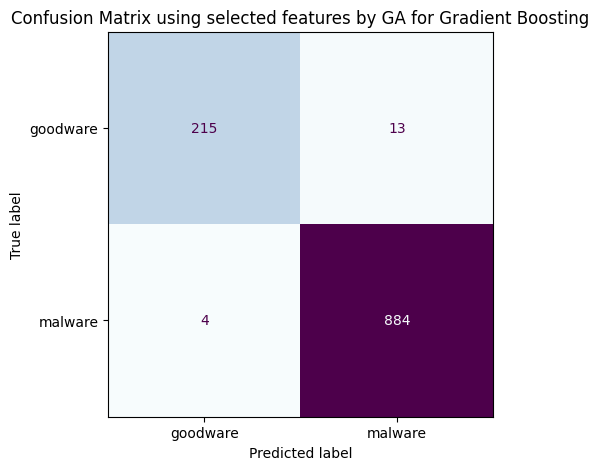

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

metrics_ga = {}

models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=SEED),
    "SVM (Linear Kernel)": SVC(kernel='linear', random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED)
}

for name, model in models.items():
    best_chromo, acc_ga, prec_ga, recall_ga, f1_ga  = run_ga_for_classifier(model, name,
                                            size=50, n_feat=X_train.shape[1], n_parents=25,
                                            mutation_rate=0.1, n_gen=30,
                                            X_train=X_train, X_test=X_test,
                                            y_train=y_train, y_test=y_test,
                                            classes=classes, X=X)

    metrics_ga[name] = {
        'Precision': prec_ga,
        'Recall': recall_ga,
        'F1-Score': f1_ga,
        'Accuracy': acc_ga
    }


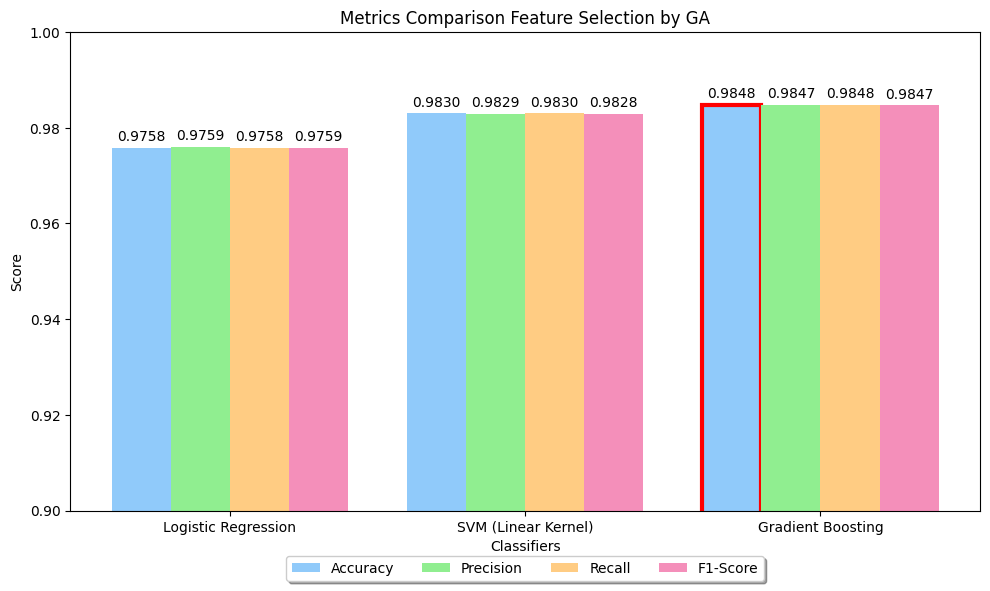

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = list(metrics_ga.keys())

# matrix
accuracies = [metrics_ga[m]['Accuracy'] for m in models]
precisions = [metrics_ga[m]['Precision'] for m in models]
recalls = [metrics_ga[m]['Recall'] for m in models]
f1_scores = [metrics_ga[m]['F1-Score'] for m in models]


x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10,6))


colors = ['#90cafa', '#90ee90', '#ffcc83', '#f48fba']


rects1 = ax.bar(x - 1.5*width, accuracies, width, label='Accuracy', color=colors[0])
rects2 = ax.bar(x - 0.5*width, precisions, width, label='Precision', color=colors[1])
rects3 = ax.bar(x + 0.5*width, recalls, width, label='Recall', color=colors[2])
rects4 = ax.bar(x + 1.5*width, f1_scores, width, label='F1-Score', color=colors[3])

max_idx = np.argmax(accuracies)
rects1[max_idx].set_edgecolor('red')
rects1[max_idx].set_linewidth(3)



ax.set_xlabel('Classifiers')
ax.set_ylabel('Score')
ax.set_title('Metrics Comparison Feature Selection by GA')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.9, 1)


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

# view Legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08),
          fancybox=True, shadow=True, ncol=4)

plt.tight_layout()
plt.show()


## **PSO**

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def run_pso_for_classifier(model, model_name, n_particles, n_iterations, n_feat,
                           X_train, X_test, y_train, y_test, classes, seed=42):
    print(f"Running PSO for {model_name}...")

    w, c1, c2 = 0.5, 1.5, 1.5
    np.random.seed(seed)

    # Initialize particles and velocities
    particles = np.random.rand(n_particles, n_feat)
    velocities = np.random.rand(n_particles, n_feat)

    # Initialize personal best positions and scores
    personal_best_positions = particles.copy()
    personal_best_scores = np.zeros(n_particles)

    # Evaluate initial particles
    for i in range(n_particles):
        selected = particles[i] > 0.5
        if np.sum(selected) == 0:
            personal_best_scores[i] = 0
        else:
            model.fit(X_train[:, selected], y_train)
            preds = model.predict(X_test[:, selected])
            personal_best_scores[i] = accuracy_score(y_test, preds)

    # Find initial global best
    global_best_idx = np.argmax(personal_best_scores)
    global_best_position = personal_best_positions[global_best_idx].copy()

    # PSO main loop
    for iteration in range(n_iterations):
        for i in range(n_particles):
            r1 = np.random.rand(n_feat)
            r2 = np.random.rand(n_feat)

            # Update velocity and position
            velocities[i] = (
                w * velocities[i]
                + c1 * r1 * (personal_best_positions[i] - particles[i])
                + c2 * r2 * (global_best_position - particles[i])
            )

            particles[i] += velocities[i]
            particles[i] = np.clip(particles[i], 0, 1)

            # Evaluate new position
            selected = particles[i] > 0.5
            if np.sum(selected) == 0:
                score = 0
            else:
                model.fit(X_train[:, selected], y_train)
                preds = model.predict(X_test[:, selected])
                score = accuracy_score(y_test, preds)

            # Update personal best
            if score > personal_best_scores[i]:
                personal_best_scores[i] = score
                personal_best_positions[i] = particles[i].copy()

        # Update global best
        global_best_idx = np.argmax(personal_best_scores)
        global_best_position = personal_best_positions[global_best_idx].copy()

        print(f"Iteration {iteration+1}/{n_iterations}, Best Accuracy: {personal_best_scores[global_best_idx]:.4f}")

    # Final results
    best_features_mask = global_best_position > 0.5
    selected_features = X.columns[best_features_mask]
    print(f"\n------------------------------------------")
    print(f"\nBest features selected by PSO for {model_name}:")
    print(selected_features)

    # Train final model using selected features
    X_train_pso = X_train[:, best_features_mask]
    X_test_pso = X_test[:, best_features_mask]
    model.fit(X_train_pso, y_train)
    pred_pso = model.predict(X_test_pso)
    acc_pso = accuracy_score(y_test, pred_pso)
    precision_pso = precision_score(y_test, pred_pso, average='weighted')
    recall_pso = recall_score(y_test, pred_pso, average='weighted')
    f1_pso = f1_score(y_test, pred_pso, average='weighted')


    print(f"\n------------------------------------------")
    print(f"\nAccuracy using PSO-selected features for {model_name}: {acc_pso*100:.2f}%\n")
    print(classification_report(y_test, pred_pso, target_names=list(classes.values())))

    # Confusion matrix
    cm_pso = confusion_matrix(y_test, pred_pso)
    cmd_pso = ConfusionMatrixDisplay(cm_pso, display_labels=list(classes.values()))

    fig, ax = plt.subplots(figsize=(5, 5))
    cmd_pso.plot(ax=ax, cmap='BuPu', colorbar=False)

    plt.title(f"\nConfusion Matrix using PSO for {model_name}")
    plt.show()

    return best_features_mask, acc_pso,precision_pso,recall_pso,f1_pso


Running PSO for Logistic Regression...
Iteration 1/50, Best Accuracy: 0.9794
Iteration 2/50, Best Accuracy: 0.9803
Iteration 3/50, Best Accuracy: 0.9803
Iteration 4/50, Best Accuracy: 0.9803
Iteration 5/50, Best Accuracy: 0.9803
Iteration 6/50, Best Accuracy: 0.9803
Iteration 7/50, Best Accuracy: 0.9803
Iteration 8/50, Best Accuracy: 0.9803
Iteration 9/50, Best Accuracy: 0.9803
Iteration 10/50, Best Accuracy: 0.9812
Iteration 11/50, Best Accuracy: 0.9812
Iteration 12/50, Best Accuracy: 0.9812
Iteration 13/50, Best Accuracy: 0.9812
Iteration 14/50, Best Accuracy: 0.9812
Iteration 15/50, Best Accuracy: 0.9812
Iteration 16/50, Best Accuracy: 0.9812
Iteration 17/50, Best Accuracy: 0.9812
Iteration 18/50, Best Accuracy: 0.9812
Iteration 19/50, Best Accuracy: 0.9812
Iteration 20/50, Best Accuracy: 0.9812
Iteration 21/50, Best Accuracy: 0.9812
Iteration 22/50, Best Accuracy: 0.9812
Iteration 23/50, Best Accuracy: 0.9812
Iteration 24/50, Best Accuracy: 0.9812
Iteration 25/50, Best Accuracy: 0.

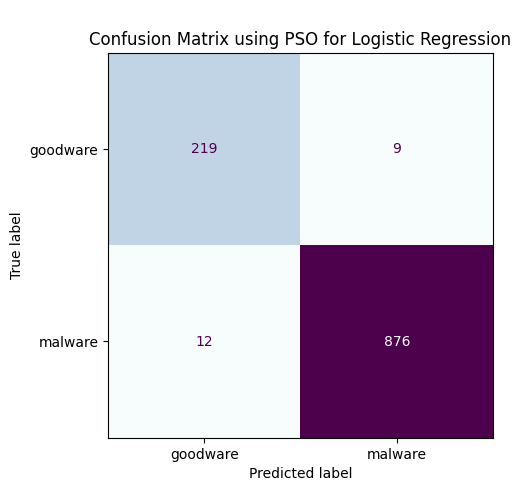

Running PSO for SVM (Linear Kernel)...
Iteration 1/50, Best Accuracy: 0.9830
Iteration 2/50, Best Accuracy: 0.9830
Iteration 3/50, Best Accuracy: 0.9848
Iteration 4/50, Best Accuracy: 0.9848
Iteration 5/50, Best Accuracy: 0.9866
Iteration 6/50, Best Accuracy: 0.9866
Iteration 7/50, Best Accuracy: 0.9866
Iteration 8/50, Best Accuracy: 0.9866
Iteration 9/50, Best Accuracy: 0.9866
Iteration 10/50, Best Accuracy: 0.9875
Iteration 11/50, Best Accuracy: 0.9875
Iteration 12/50, Best Accuracy: 0.9875
Iteration 13/50, Best Accuracy: 0.9875
Iteration 14/50, Best Accuracy: 0.9875
Iteration 15/50, Best Accuracy: 0.9875
Iteration 16/50, Best Accuracy: 0.9875
Iteration 17/50, Best Accuracy: 0.9875
Iteration 18/50, Best Accuracy: 0.9875
Iteration 19/50, Best Accuracy: 0.9875
Iteration 20/50, Best Accuracy: 0.9875
Iteration 21/50, Best Accuracy: 0.9875
Iteration 22/50, Best Accuracy: 0.9875
Iteration 23/50, Best Accuracy: 0.9875
Iteration 24/50, Best Accuracy: 0.9875
Iteration 25/50, Best Accuracy: 0.

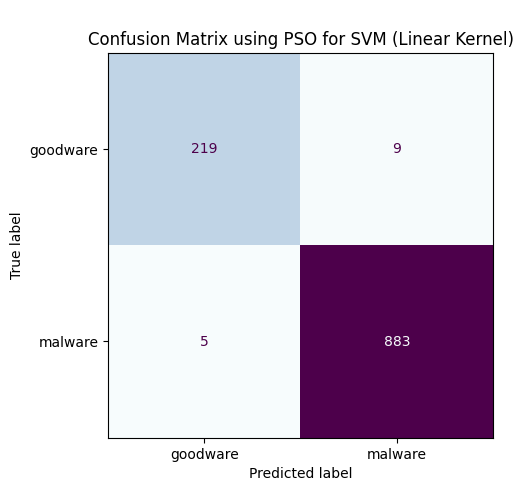

Running PSO for Gradient Boosting...
Iteration 1/50, Best Accuracy: 0.9866
Iteration 2/50, Best Accuracy: 0.9875
Iteration 3/50, Best Accuracy: 0.9875
Iteration 4/50, Best Accuracy: 0.9875
Iteration 5/50, Best Accuracy: 0.9875
Iteration 6/50, Best Accuracy: 0.9875
Iteration 7/50, Best Accuracy: 0.9875
Iteration 8/50, Best Accuracy: 0.9884
Iteration 9/50, Best Accuracy: 0.9884
Iteration 10/50, Best Accuracy: 0.9884
Iteration 11/50, Best Accuracy: 0.9884
Iteration 12/50, Best Accuracy: 0.9884
Iteration 13/50, Best Accuracy: 0.9884
Iteration 14/50, Best Accuracy: 0.9884
Iteration 15/50, Best Accuracy: 0.9884
Iteration 16/50, Best Accuracy: 0.9884
Iteration 17/50, Best Accuracy: 0.9884
Iteration 18/50, Best Accuracy: 0.9884
Iteration 19/50, Best Accuracy: 0.9884
Iteration 20/50, Best Accuracy: 0.9892
Iteration 21/50, Best Accuracy: 0.9892
Iteration 22/50, Best Accuracy: 0.9892
Iteration 23/50, Best Accuracy: 0.9892
Iteration 24/50, Best Accuracy: 0.9892
Iteration 25/50, Best Accuracy: 0.98

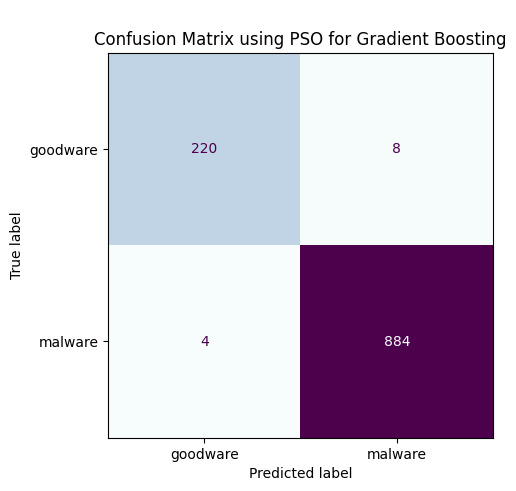

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
metrics_pso = {}

models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=SEED),
    "SVM (Linear Kernel)": SVC(kernel='linear', random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED)
}

for name, model in models.items():
    best_mask, acc_pso,precision_pso,recall_pso,f1_pso = run_pso_for_classifier(model, name,
                                            n_particles=30, n_iterations=50, n_feat=X_train.shape[1],
                                            X_train=X_train, X_test=X_test,
                                            y_train=y_train, y_test=y_test,
                                            classes=classes, seed=SEED)



    metrics_pso[name] = {
        'Precision': precision_pso,
        'Recall': recall_pso,
        'F1-Score': f1_pso,
        'Accuracy': acc_pso
    }



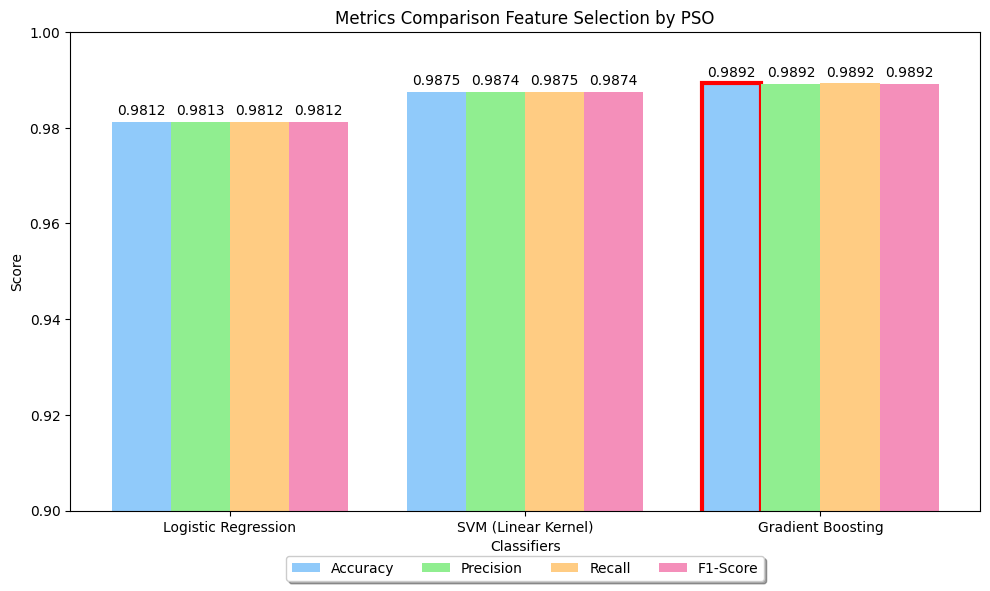

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = list(metrics_pso.keys())

# matrix
accuracies = [metrics_pso[m]['Accuracy'] for m in models]
precisions = [metrics_pso[m]['Precision'] for m in models]
recalls = [metrics_pso[m]['Recall'] for m in models]
f1_scores = [metrics_pso[m]['F1-Score'] for m in models]


x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10,6))


colors = ['#90cafa', '#90ee90', '#ffcc83', '#f48fba']


rects1 = ax.bar(x - 1.5*width, accuracies, width, label='Accuracy', color=colors[0])
rects2 = ax.bar(x - 0.5*width, precisions, width, label='Precision', color=colors[1])
rects3 = ax.bar(x + 0.5*width, recalls, width, label='Recall', color=colors[2])
rects4 = ax.bar(x + 1.5*width, f1_scores, width, label='F1-Score', color=colors[3])

max_idx = np.argmax(accuracies)
rects1[max_idx].set_edgecolor('red')
rects1[max_idx].set_linewidth(3)



ax.set_xlabel('Classifiers')
ax.set_ylabel('Score')
ax.set_title('Metrics Comparison Feature Selection by PSO')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.9, 1)


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

# view Legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08),
          fancybox=True, shadow=True, ncol=4)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

def plot_metrics_table(classifier_name, metrics_no_selection, metrics_ga, metrics_pso):
    fig, ax = plt.subplots(figsize=(7, 2))

    # البيانات
    cell_text = []
    rows = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
    cols = ['Baseline', 'GA', 'PSO']

    for metric in rows:
        row = [
            f"{metrics_no_selection[classifier_name][metric]:.4f}",
            f"{metrics_ga[classifier_name][metric]:.4f}",
            f"{metrics_pso[classifier_name][metric]:.4f}"
        ]
        cell_text.append(row)

    # إنشاء الجدول
    table = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
                     loc='center', cellLoc='center', colLoc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)  # توسيع الصفوف شوية

    ax.axis('off')
    plt.title(f"\n\n\n\nPerformance Metrics Table for {classifier_name}", fontsize=14, pad=20)
    plt.show()





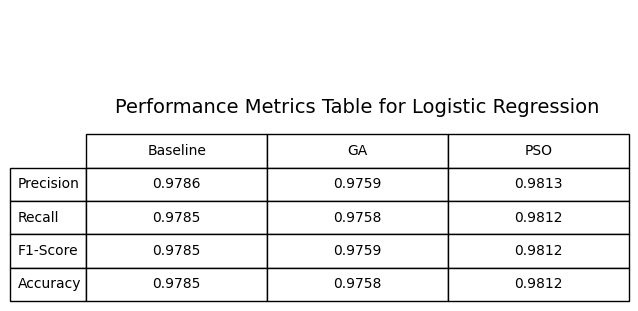

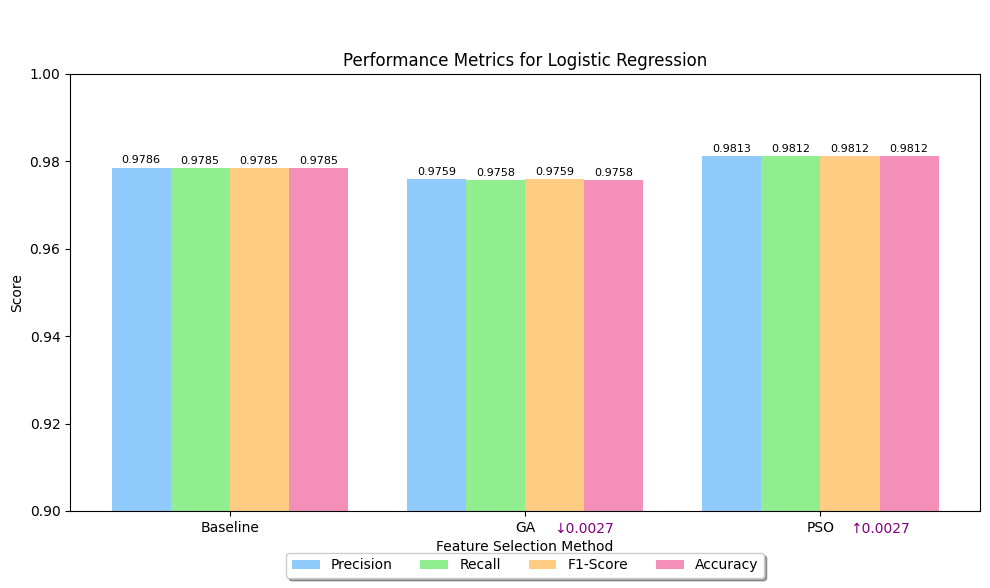

_____________________________________________________________________________________________________________________________________




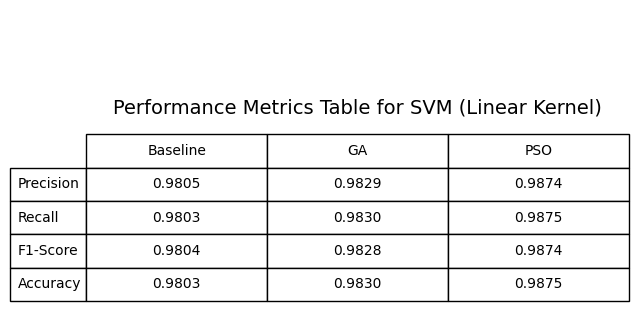

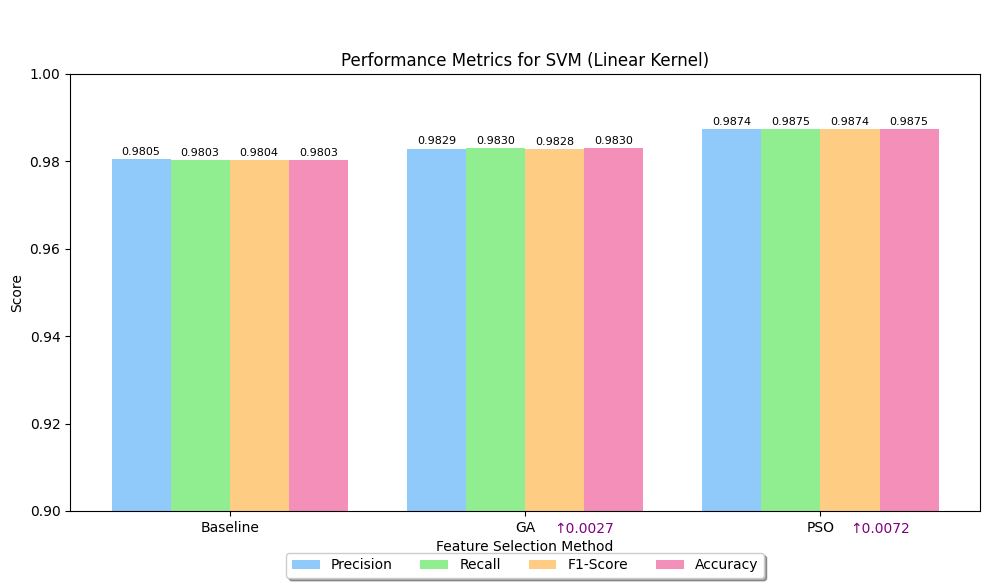

_____________________________________________________________________________________________________________________________________




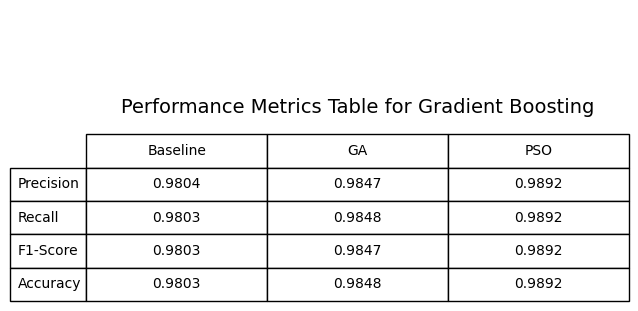

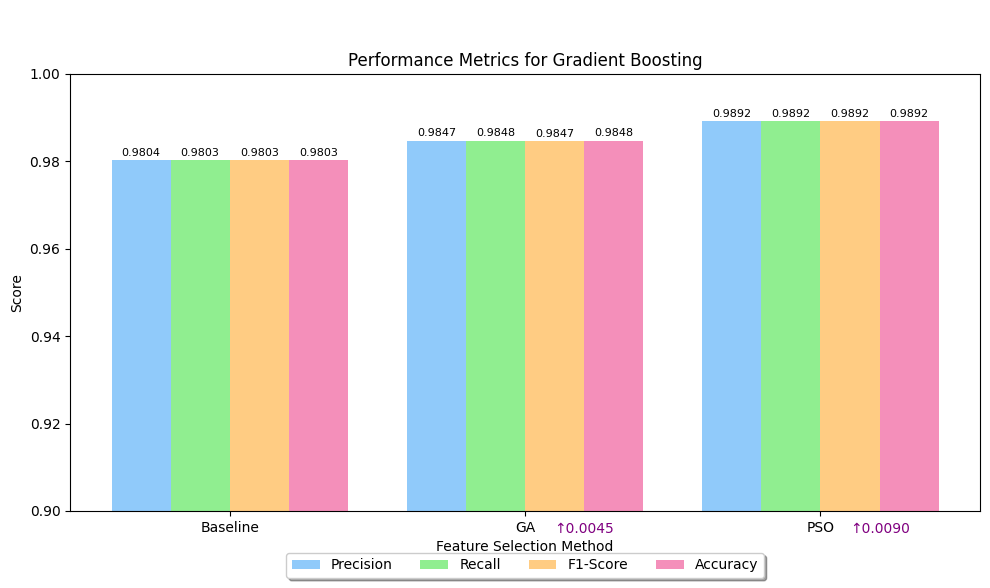

_____________________________________________________________________________________________________________________________________




In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics_grouped(classifier_name, metrics_no_selection, metrics_ga, metrics_pso):
    methods = ['Baseline', 'GA', 'PSO']
    metrics = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
    x = np.arange(len(methods))
    width = 0.2

    # القيم
    precision_values = [metrics_no_selection[classifier_name]['Precision'],
                        metrics_ga[classifier_name]['Precision'],
                        metrics_pso[classifier_name]['Precision']]

    recall_values = [metrics_no_selection[classifier_name]['Recall'],
                     metrics_ga[classifier_name]['Recall'],
                     metrics_pso[classifier_name]['Recall']]

    f1_values = [metrics_no_selection[classifier_name]['F1-Score'],
                 metrics_ga[classifier_name]['F1-Score'],
                 metrics_pso[classifier_name]['F1-Score']]

    acc_values = [metrics_no_selection[classifier_name]['Accuracy'],
                  metrics_ga[classifier_name]['Accuracy'],
                  metrics_pso[classifier_name]['Accuracy']]

    fig, ax = plt.subplots(figsize=(10, 6))

    colors = ['#90cafa', '#90ee90', '#ffcc83', '#f48fba']

    rects1 = ax.bar(x - 1.5*width, precision_values, width, label='Precision', color=colors[0])
    rects2 = ax.bar(x - 0.5*width, recall_values, width, label='Recall', color=colors[1])
    rects3 = ax.bar(x + 0.5*width, f1_values, width, label='F1-Score', color=colors[2])
    rects4 = ax.bar(x + 1.5*width, acc_values, width, label='Accuracy', color=colors[3])

    ax.set_xlabel('Feature Selection Method\n')
    ax.set_ylabel('Score')
    ax.set_title(f'\n\nPerformance Metrics for {classifier_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylim(0.9, 1)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08),
              fancybox=True, shadow=True, ncol=4)

    # عرض القيم فوق الأعمدة
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', fontsize=8)

    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)
    autolabel(rects4)

    # مقارنة Accuracy بتاعة GA و PSO مع Baseline
    baseline_acc = acc_values[0]
    ga_acc = acc_values[1]
    pso_acc = acc_values[2]

    diff_ga = ga_acc - baseline_acc
    diff_pso = pso_acc - baseline_acc

    ga_text = f'↑{diff_ga:.4f}' if diff_ga > 0 else f'↓{abs(diff_ga):.4f}'
    pso_text = f'↑{diff_pso:.4f}' if diff_pso > 0 else f'↓{abs(diff_pso):.4f}'

    ax.text(x[1] + 0.1, 0.895, ga_text, ha='left', fontsize=10, color='purple')
    ax.text(x[2] + 0.1, 0.895, pso_text, ha='left', fontsize=10, color='purple')
    fig.tight_layout()
    plt.show()

# تنفيذ الرسم لكل Classifier
for clf in ['Logistic Regression', 'SVM (Linear Kernel)', 'Gradient Boosting']:
   plot_metrics_table(clf, metrics_no_selection, metrics_ga, metrics_pso)
   plot_metrics_grouped(clf, metrics_no_selection, metrics_ga, metrics_pso)
   print("_____________________________________________________________________________________________________________________________________\n\n")
